# Transformations example

In [16]:
from hyppopipe.data.image import Image
from hyppopipe.pipeline.image.transform import ImageTransformer
from hyppopipe.pipeline import Pipeline, Step

from torchvision.transforms import v2 as transforms

In [19]:
image_data_processing = Pipeline(
    {
        "GetResizedImage": Step(
            ImageTransformer().resize(224),
            inputs=["__input__"],
        ),
        "GetSharpenImage": Step(
            ImageTransformer().sharpen(2.0),
            inputs=["GetResizedImage"],
        ),
        "GetBluredImage": Step(
            ImageTransformer().gaussian_blur(5, sigma=(0.1, 2.0)),
            inputs=["GetResizedImage"],
        ),
        # Or we can use fluent transformations:
        "FluentTransformations": Step(
            ImageTransformer().resize(224).gaussian_blur(5, sigma=(0.1, 2.0)).rotate(90),
            inputs=["__input__"],
        ),
        # Or composed transformations:
        "ComposedTransformations": Step(
            ImageTransformer.from_compose(
                transforms.Compose([
                    transforms.Resize(224),
                    transforms.GaussianBlur(5, sigma=(0.1, 2.0)),
                    transforms.RandomRotation((90, 90)),
                ])
            ),
            inputs=["__input__"],
        )

    },
    shift_result=False,
)

In [20]:
original_image = Image.from_path("images/image74prime.tif")

pipeline_result = image_data_processing.predict(original_image)

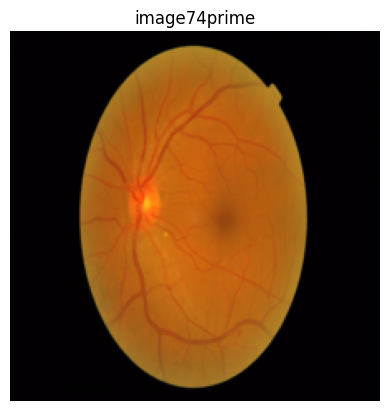

In [21]:
pipeline_result.outputs["GetResizedImage"].show()

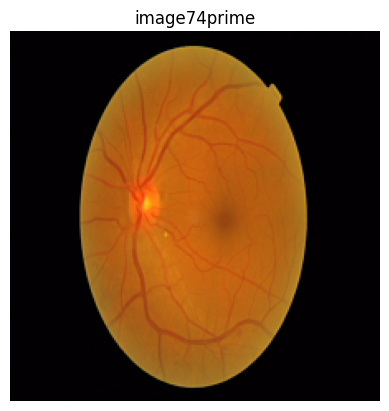

In [22]:
pipeline_result.outputs["GetSharpenImage"].show()

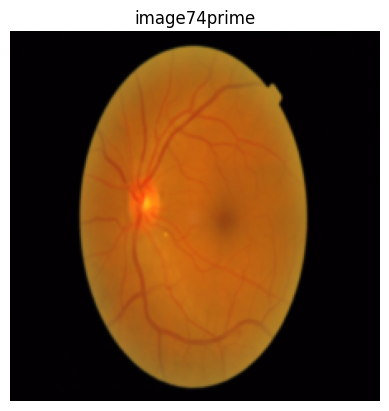

In [23]:
pipeline_result.outputs["GetBluredImage"].show()

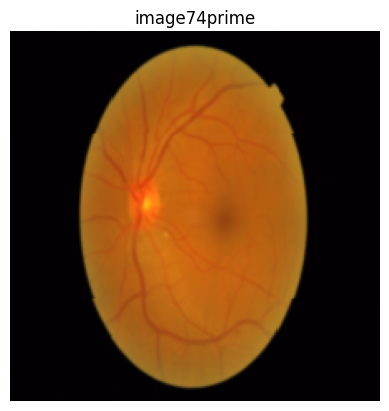

In [24]:
pipeline_result.outputs["FluentTransformations"].show()

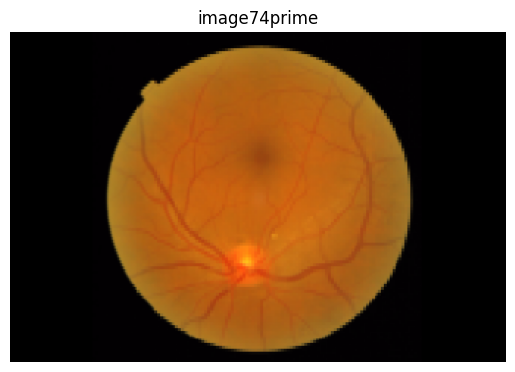

In [25]:
pipeline_result.outputs["ComposedTransformations"].show()